# Exploring the Iris dataset with pandas and visualisations

**UWE Bristol · Introduction to Machine Learning**

Before we train any model, we need to **understand our data**. This is called
**exploratory data analysis (EDA)**. In this notebook we will:

1. Load the Iris dataset into a pandas **DataFrame**
2. Use pandas to inspect, summarise, filter, group and reshape the data
3. Draw a range of charts to see patterns that tables can hide
4. Finish with some questions for you to try

**The dataset:** 150 iris flowers, 50 from each of 3 species (*setosa*, *versicolor*, *virginica*).
Each flower has 4 measurements in centimetres: sepal length, sepal width, petal length and petal width.

Run each cell in order with **Shift + Enter**.

## 1. Setting up

In [1]:
# pandas: tables of data (DataFrames)
import pandas as pd
# numpy: fast maths on arrays of numbers
import numpy as np
# matplotlib: the standard Python plotting library
import matplotlib.pyplot as plt
# seaborn: builds on matplotlib to make statistical charts easier
import seaborn as sns
# scikit-learn ships with the Iris dataset, so no download is needed
from sklearn.datasets import load_iris

# Make charts a sensible size and style
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

# One fixed colour and marker per species, used in every chart,
# so the same species always looks the same
SPECIES_COLOURS = {"setosa": "#2a78d6", "versicolor": "#eb6834", "virginica": "#1baf7a"}
SPECIES_MARKERS = {"setosa": "o", "versicolor": "s", "virginica": "^"}

## 2. Loading the data into a DataFrame

`load_iris(as_frame=True)` gives us the data as a pandas DataFrame. The species are stored
as numbers (0, 1, 2), so we swap them for their names to make the data easier to read.

In [2]:
# Load the dataset as pandas objects
iris = load_iris(as_frame=True)

# iris.frame holds the 4 feature columns plus a 'target' column (0, 1 or 2)
df = iris.frame.copy()

# Give the columns short, simple names without spaces or units
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

# Replace the numbers 0, 1, 2 with the species names
df["species"] = df["species"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

# Show the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


> **Tip:** you could also load the same data with `sns.load_dataset("iris")`, which downloads it
> from the internet, or from a CSV file with `pd.read_csv("iris.csv")`.

## 3. First look: size, columns and types

These are the first commands to run on **any** new dataset.

In [3]:
# The last 5 rows
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [4]:
# 5 random rows (random_state makes the choice repeatable)
df.sample(5, random_state=42)

,sepal_length,sepal_width,petal_length,petal_width,species
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor


In [5]:
# (number of rows, number of columns)
print("Shape:", df.shape)
print("Rows:", len(df))
print("Column names:", list(df.columns))

Shape: (150, 5)
Rows: 150
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [6]:
# The data type of each column: float64 = decimal numbers, object/str = text
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [7]:
# A compact summary: column names, how many non-missing values, and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## 4. Summary statistics

`describe()` gives the count, mean, standard deviation, minimum, quartiles and maximum
of every numeric column.

**Question:** which measurement varies the most? (Look at the `std` row.)

In [8]:
# Summary statistics, rounded to 2 decimal places
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [9]:
# Transposing (.T) swaps rows and columns, which is often easier to read
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5


In [10]:
# Individual statistics for one column
print("Mean petal length:  ", round(df["petal_length"].mean(), 2))
print("Median petal length:", df["petal_length"].median())
print("Smallest petal:     ", df["petal_length"].min())
print("Largest petal:      ", df["petal_length"].max())
print("Range:              ", round(df["petal_length"].max() - df["petal_length"].min(), 2))

Mean petal length:   3.76
Median petal length: 4.35
Smallest petal:      1.0
Largest petal:       6.9
Range:               5.9


## 5. Data quality: missing values and duplicates

Real datasets are often messy. Always check for missing values and repeated rows.

In [11]:
# Count missing (NaN) values in each column
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [12]:
# How many rows are exact copies of an earlier row?
print("Duplicate rows:", df.duplicated().sum())

# keep=False shows every copy, so we can see both rows side by side
df[df.duplicated(keep=False)]

Duplicate rows: 1


,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


Iris has **no missing values** but it does contain **one duplicated flower**. With real data we
would ask: is this a genuine second flower with identical measurements, or a data-entry mistake?
Here we keep it, but it is worth noticing.

## 6. Looking at the label: is the dataset balanced?

The `species` column is our **label**. A balanced dataset has roughly the same number of
examples of each class.

In [13]:
# How many flowers of each species?
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [14]:
# The same as proportions (normalize=True) instead of counts
df["species"].value_counts(normalize=True).round(3)

species
setosa        0.333
versicolor    0.333
virginica     0.333
Name: proportion, dtype: float64

In [15]:
# How many different species are there, and what are they?
print("Number of species:", df["species"].nunique())
print("Species:", list(df["species"].unique()))

Number of species: 3
Species: ['setosa', 'versicolor', 'virginica']


## 7. Selecting columns and rows

- `df["col"]` selects one column (a **Series**)
- `df[["col1", "col2"]]` selects several columns (a **DataFrame**)
- `df.loc[...]` selects by **label**; `df.iloc[...]` selects by **position**

In [16]:
# One column: a pandas Series
df["petal_length"].head()

0    1.4
1    1.4
2    1.3
3    1.5
4    1.4
Name: petal_length, dtype: float64

In [17]:
# Two columns: note the double square brackets
df[["petal_length", "species"]].head()

,petal_length,species
0,1.4,setosa
1,1.4,setosa
2,1.3,setosa
3,1.5,setosa
4,1.4,setosa


In [18]:
# loc: rows labelled 10 to 14 (inclusive), and two named columns
df.loc[10:14, ["sepal_length", "species"]]

,sepal_length,species
10,5.4,setosa
11,4.8,setosa
12,4.8,setosa
13,4.3,setosa
14,5.8,setosa


In [19]:
# iloc: the first 3 rows and the first 2 columns, by position (the end is excluded)
df.iloc[0:3, 0:2]

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2


## 8. Filtering: asking questions of the data

We filter with **conditions** that are True or False for each row.

In [20]:
# Flowers with long petals (more than 6 cm)
long_petals = df[df["petal_length"] > 6]
print(len(long_petals), "flowers have petals longer than 6 cm")
long_petals

9 flowers have petals longer than 6 cm


,sepal_length,sepal_width,petal_length,petal_width,species
105,7.6,3.0,6.6,2.1,virginica
107,7.3,2.9,6.3,1.8,virginica
109,7.2,3.6,6.1,2.5,virginica
117,7.7,3.8,6.7,2.2,virginica
118,7.7,2.6,6.9,2.3,virginica
122,7.7,2.8,6.7,2.0,virginica
130,7.4,2.8,6.1,1.9,virginica
131,7.9,3.8,6.4,2.0,virginica
135,7.7,3.0,6.1,2.3,virginica


In [21]:
# Which species do those long-petalled flowers belong to?
long_petals["species"].value_counts()

species
virginica    9
Name: count, dtype: int64

In [22]:
# Two conditions at once: & means AND, | means OR. Each condition needs brackets.
wide_short_sepals = df[(df["sepal_width"] > 3.5) & (df["sepal_length"] < 5.5)]
wide_short_sepals["species"].value_counts()

species
setosa    12
Name: count, dtype: int64

In [23]:
# query() does the same thing with more readable text
df.query("species == 'versicolor' and petal_width >= 1.6")

,sepal_length,sepal_width,petal_length,petal_width,species
56,6.3,3.3,4.7,1.6,versicolor
70,5.9,3.2,4.8,1.8,versicolor
77,6.7,3.0,5.0,1.7,versicolor
83,6.0,2.7,5.1,1.6,versicolor
85,6.0,3.4,4.5,1.6,versicolor


In [24]:
# isin() keeps rows whose value is in a list
df[df["species"].isin(["setosa", "virginica"])].shape

(100, 5)

## 9. Sorting and ranking

In [25]:
# The 5 flowers with the longest sepals
df.sort_values("sepal_length", ascending=False).head()

,sepal_length,sepal_width,petal_length,petal_width,species
131,7.9,3.8,6.4,2.0,virginica
122,7.7,2.8,6.7,2.0,virginica
118,7.7,2.6,6.9,2.3,virginica
117,7.7,3.8,6.7,2.2,virginica
135,7.7,3.0,6.1,2.3,virginica


In [26]:
# nsmallest / nlargest are shortcuts for the same idea
df.nsmallest(3, "petal_width")

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
12,4.8,3.0,1.4,0.1,setosa
13,4.3,3.0,1.1,0.1,setosa


In [27]:
# Which row has the biggest petal? idxmax gives its index label
biggest = df["petal_length"].idxmax()
df.loc[biggest]

sepal_length          7.7
sepal_width           2.6
petal_length          6.9
petal_width           2.3
species         virginica
Name: 118, dtype: object

## 10. Grouping: comparing the species

`groupby()` splits the data into groups, calculates something for each group, and combines the
results. This is one of the most useful tools in pandas.

In [28]:
# Average of every measurement, for each species
df.groupby("species").mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [29]:
# Several statistics at once for one column
df.groupby("species")["petal_length"].agg(["min", "mean", "median", "max", "std"]).round(2)

,min,mean,median,max,std
species,,,,,
setosa,1.0,1.46,1.50,1.9,0.17
versicolor,3.0,4.26,4.35,5.1,0.47
virginica,4.5,5.55,5.55,6.9,0.55


In [30]:
# Different statistics for different columns
df.groupby("species").agg(
    avg_petal_length=("petal_length", "mean"),
    max_sepal_width=("sepal_width", "max"),
    count=("species", "size"),
).round(2)

,avg_petal_length,max_sepal_width,count
species,,,
setosa,1.46,4.4,50
versicolor,4.26,3.4,50
virginica,5.55,3.8,50


**What do you notice?** Setosa petals are far smaller than the other two species, while the
sepal measurements are much more similar across species. That suggests petal measurements will
be more useful for telling the species apart.

## 11. Creating new columns (feature engineering)

We can combine existing columns to create new **features**.

In [31]:
# Approximate petal area (length × width)
df["petal_area"] = df["petal_length"] * df["petal_width"]

# Ratio of sepal length to sepal width: how long and thin is the sepal?
df["sepal_ratio"] = (df["sepal_length"] / df["sepal_width"]).round(2)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_area,sepal_ratio
0,5.1,3.5,1.4,0.2,setosa,0.28,1.46
1,4.9,3.0,1.4,0.2,setosa,0.28,1.63
2,4.7,3.2,1.3,0.2,setosa,0.26,1.47
3,4.6,3.1,1.5,0.2,setosa,0.30,1.48
4,5.0,3.6,1.4,0.2,setosa,0.28,1.39


In [32]:
# Put petal length into three size bands with pd.cut
df["petal_size"] = pd.cut(
    df["petal_length"],
    bins=[0, 2.5, 5.0, 7.0],
    labels=["small", "medium", "large"],
)
df["petal_size"].value_counts()

petal_size
medium    58
small     50
large     42
Name: count, dtype: int64

In [33]:
# A cross-tabulation counts every combination of two columns
pd.crosstab(df["species"], df["petal_size"])

petal_size,small,medium,large
species,,,
setosa,50,0,0
versicolor,0,49,1
virginica,0,9,41


Every setosa has **small** petals and no other species does. A single rule
("if petal length < 2.5 cm, it's setosa") would classify setosa perfectly.

## 12. Correlation: which measurements move together?

Correlation runs from **−1** (as one goes up, the other goes down) through **0** (no straight-line
relationship) to **+1** (they rise together).

In [34]:
# The four original measurements only
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df[features].corr().round(2)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


Petal length and petal width are very strongly correlated (0.96): they carry
similar information. Across all flowers, sepal width has only a weak-to-moderate *negative* relationship
with the others (−0.12 to −0.43), but we will see in the charts that this picture changes **within** each species.

## 13. Reshaping: wide and long format

Our table is in **wide** format (one column per measurement). Some tools, including many
seaborn charts, prefer **long** format: one row per single measurement.

In [35]:
# melt() turns the 4 measurement columns into two columns: 'measurement' and 'cm'
long_df = df.melt(id_vars="species", value_vars=features,
                  var_name="measurement", value_name="cm")
print("Wide shape:", df[features + ["species"]].shape, "  Long shape:", long_df.shape)
long_df.head()

Wide shape: (150, 5)   Long shape: (600, 3)


,species,measurement,cm
0,setosa,sepal_length,5.1
1,setosa,sepal_length,4.9
2,setosa,sepal_length,4.7
3,setosa,sepal_length,4.6
4,setosa,sepal_length,5.0


In [36]:
# pivot_table() goes the other way and summarises at the same time
long_df.pivot_table(index="measurement", columns="species", values="cm", aggfunc="mean").round(2)

species,setosa,versicolor,virginica
measurement,,,
petal_length,1.46,4.26,5.55
petal_width,0.25,1.33,2.03
sepal_length,5.01,5.94,6.59
sepal_width,3.43,2.77,2.97


---
# Part 2: Visualising the data

Tables are precise, but charts show **shapes, overlaps and outliers** at a glance.
Each chart below answers a different question.

### Chart 1: How many flowers of each species? (bar chart)

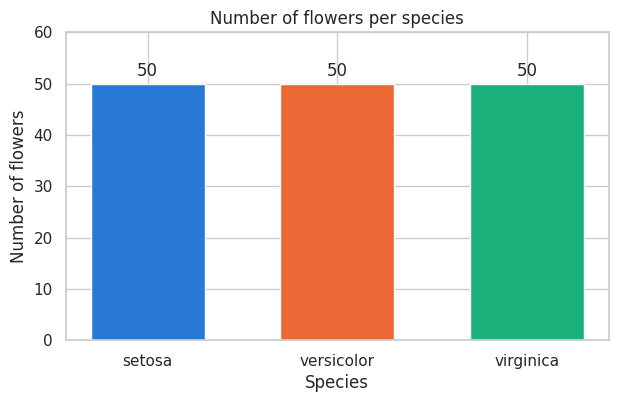

In [37]:
counts = df["species"].value_counts().reindex(SPECIES_COLOURS.keys())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=[SPECIES_COLOURS[s] for s in counts.index], width=0.6)
# Write the count on top of each bar
ax.bar_label(bars, padding=3)
ax.set_title("Number of flowers per species")
ax.set_xlabel("Species")
ax.set_ylabel("Number of flowers")
ax.set_ylim(0, 60)
plt.show()

A perfectly **balanced** dataset: 50 of each. With imbalanced data, accuracy can be misleading.

### Chart 2: How is one measurement distributed? (histogram)

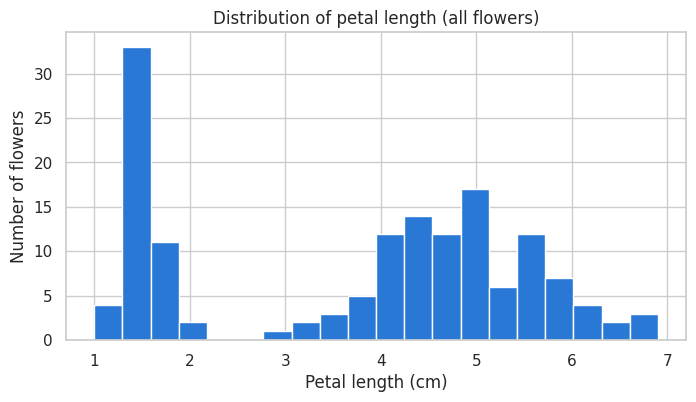

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["petal_length"], bins=20, color="#2a78d6", edgecolor="white")
ax.set_title("Distribution of petal length (all flowers)")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Number of flowers")
plt.show()

There are **two humps** (a *bimodal* distribution) with a gap around 2–3 cm. That gap is a clue
that there are different groups of flowers hidden in the data.

### Chart 3: The same histogram, split by species

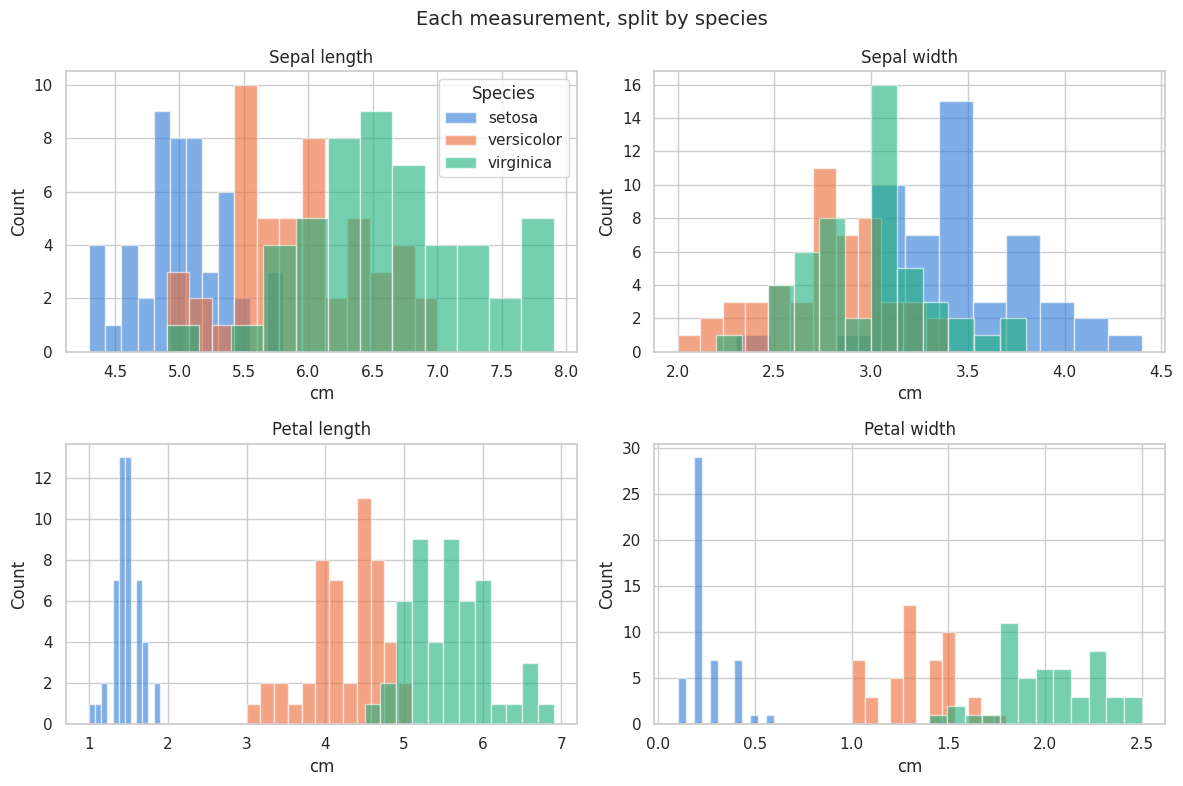

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop over the 4 measurements and the 4 subplots together
for ax, feature in zip(axes.flat, features):
    for species, colour in SPECIES_COLOURS.items():
        values = df.loc[df["species"] == species, feature]
        ax.hist(values, bins=12, alpha=0.6, color=colour, label=species, edgecolor="white")
    ax.set_title(feature.replace("_", " ").capitalize())
    ax.set_xlabel("cm")
    ax.set_ylabel("Count")

axes[0, 0].legend(title="Species")
fig.suptitle("Each measurement, split by species", fontsize=14)
plt.tight_layout()
plt.show()

The petal charts (bottom row) show the species well separated. The sepal charts (top row) overlap
heavily, so sepals on their own are less useful for classification.

### Chart 4: Comparing spread and outliers (box plots)

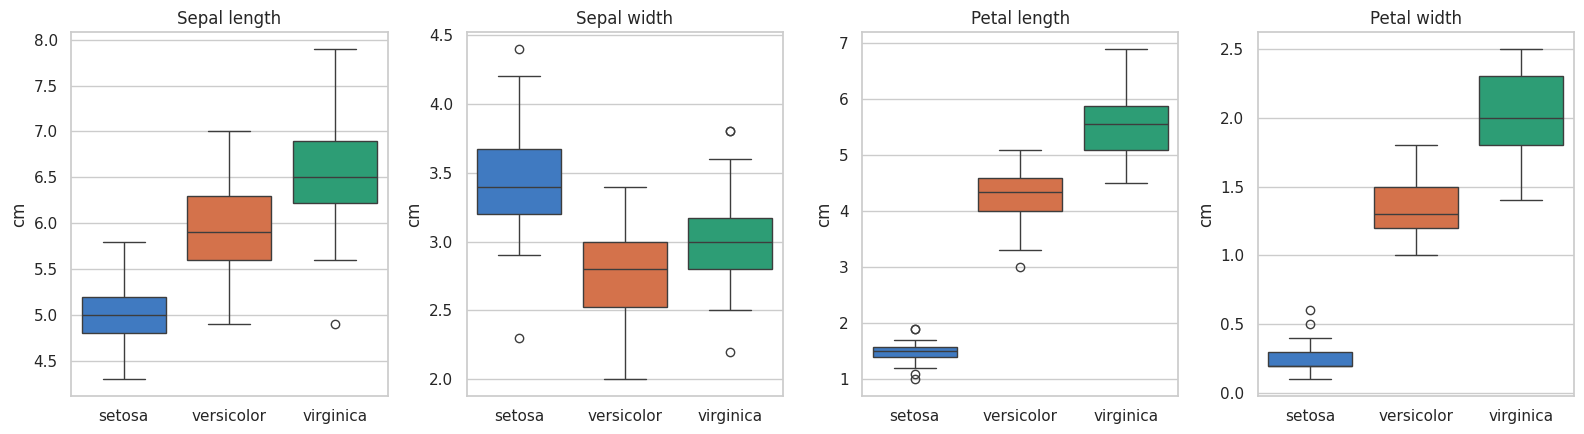

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, feature in zip(axes, features):
    sns.boxplot(data=df, x="species", y=feature, hue="species",
                palette=SPECIES_COLOURS, ax=ax, legend=False)
    ax.set_title(feature.replace("_", " ").capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("cm")
plt.tight_layout()
plt.show()

**How to read a box plot:** the line in the box is the median, the box covers the middle 50% of
flowers, the whiskers show the typical range, and dots beyond them are possible **outliers**.

### Chart 5: The full shape of each distribution (violin plot)

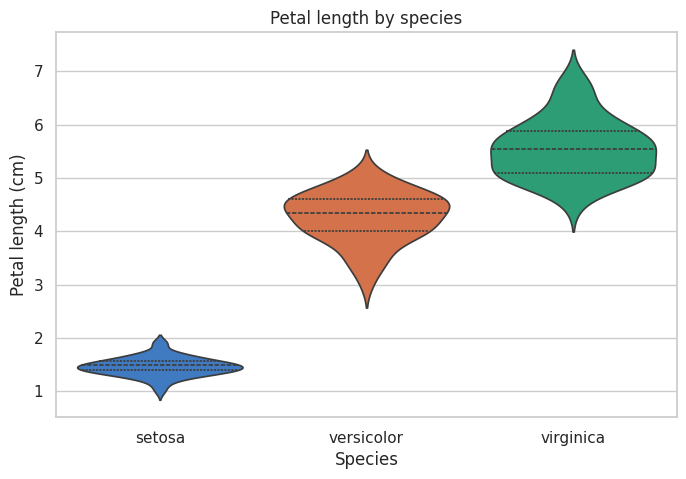

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="species", y="petal_length", hue="species",
               palette=SPECIES_COLOURS, inner="quartile", legend=False, ax=ax)
ax.set_title("Petal length by species")
ax.set_xlabel("Species")
ax.set_ylabel("Petal length (cm)")
plt.show()

A violin plot is a box plot combined with a smoothed histogram: wider means more flowers at that value.

### Chart 6: Every single flower (strip plot)

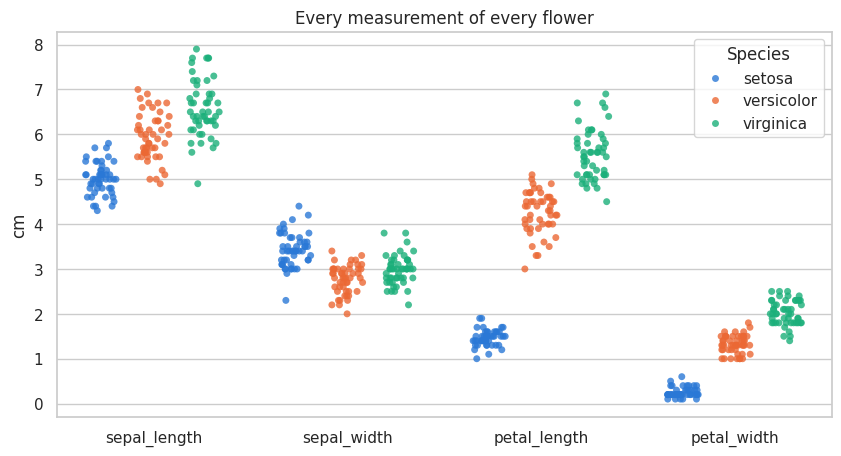

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
# long_df has one row per measurement, so we can show all 4 measurements together
sns.stripplot(data=long_df, x="measurement", y="cm", hue="species",
              palette=SPECIES_COLOURS, dodge=True, jitter=0.25, alpha=0.8, size=5, ax=ax)
ax.set_title("Every measurement of every flower")
ax.set_xlabel("")
ax.set_ylabel("cm")
ax.legend(title="Species")
plt.show()

Unlike a box plot, a strip plot hides nothing: each dot is one real measurement.

### Chart 7: Two measurements together (scatter plot of sepals)

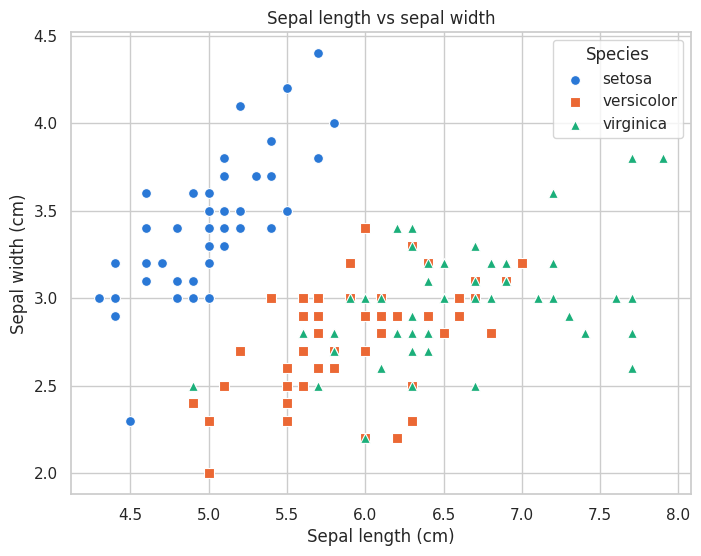

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
for species, colour in SPECIES_COLOURS.items():
    subset = df[df["species"] == species]
    ax.scatter(subset["sepal_length"], subset["sepal_width"], color=colour,
               marker=SPECIES_MARKERS[species], label=species, s=50,
               edgecolor="white", linewidth=0.8)
ax.set_title("Sepal length vs sepal width")
ax.set_xlabel("Sepal length (cm)")
ax.set_ylabel("Sepal width (cm)")
ax.legend(title="Species")
plt.show()

Setosa stands apart, but **versicolor and virginica are mixed together**: sepals alone would lead to mistakes.

### Chart 8: Scatter plot of petals

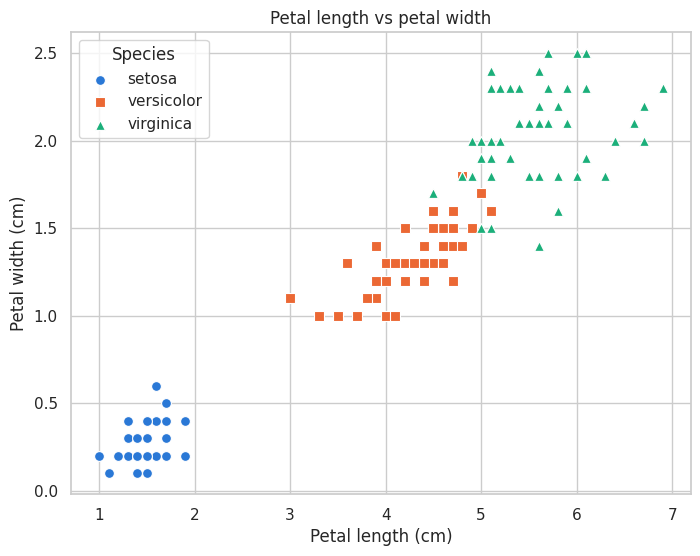

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
for species, colour in SPECIES_COLOURS.items():
    subset = df[df["species"] == species]
    ax.scatter(subset["petal_length"], subset["petal_width"], color=colour,
               marker=SPECIES_MARKERS[species], label=species, s=50,
               edgecolor="white", linewidth=0.8)
ax.set_title("Petal length vs petal width")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.legend(title="Species")
plt.show()

Much clearer: three groups, with only a small overlap between versicolor and virginica.
You could almost draw the classification boundaries by hand.

### Chart 9: Every pair of measurements at once (pair plot)

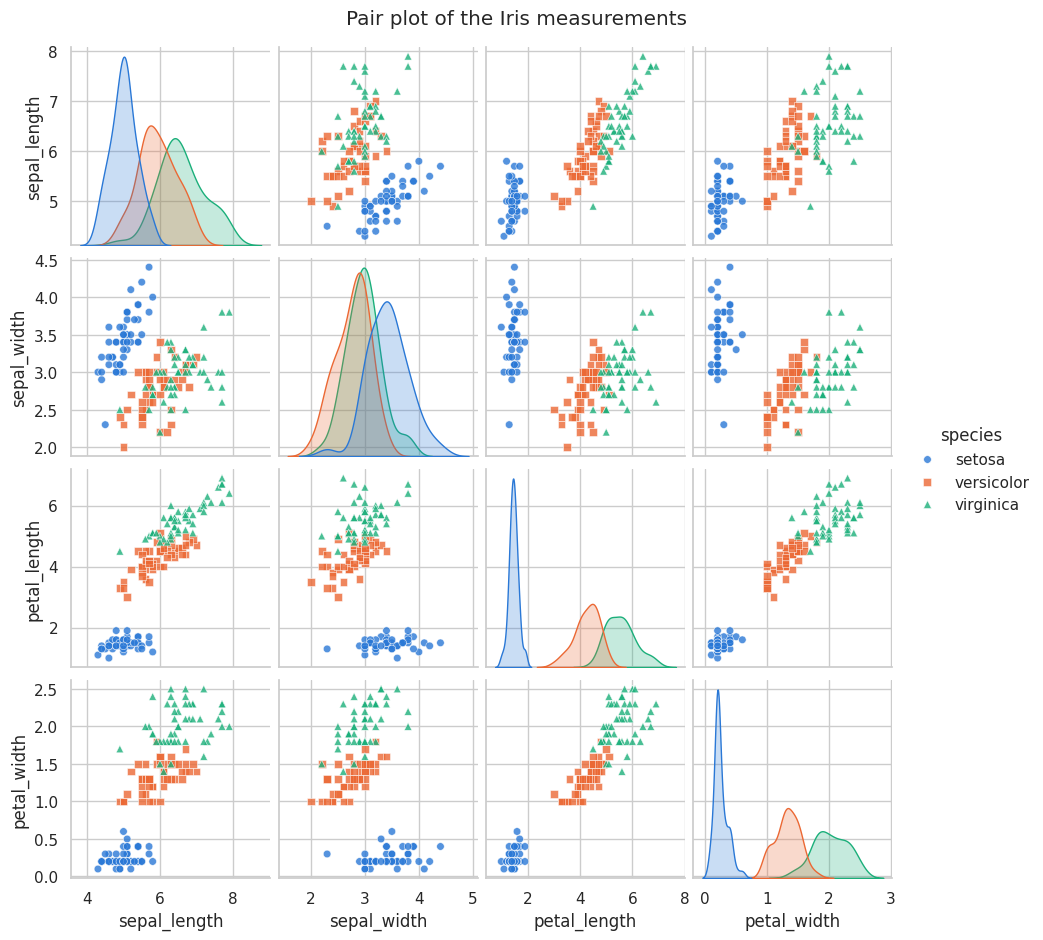

In [45]:
# A grid of scatter plots for every pair of features,
# with each feature's distribution on the diagonal
g = sns.pairplot(df, vars=features, hue="species", palette=SPECIES_COLOURS,
                 markers=["o", "s", "^"], height=2.3, plot_kws={"s": 30, "alpha": 0.8})
g.figure.suptitle("Pair plot of the Iris measurements", y=1.02)
plt.show()

The pair plot is often the **single most useful** EDA chart for a small dataset.
Find the panel where the three species are best separated.

### Chart 10: Correlation heatmap

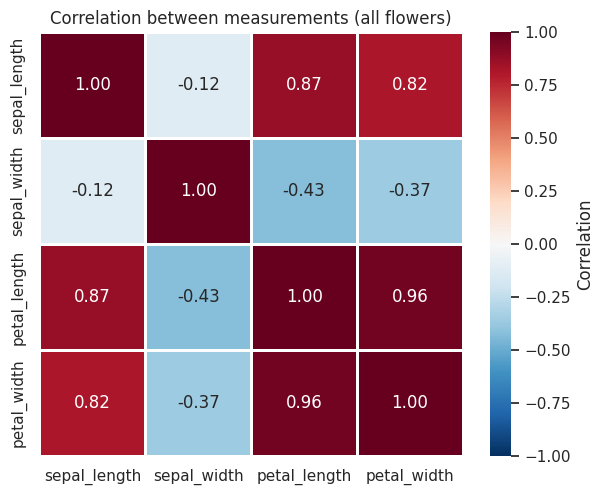

In [46]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
# A diverging colour scale: blue = negative, red = positive, white = no correlation
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation between measurements (all flowers)")
plt.show()

### Chart 11: Correlation can hide what happens inside groups

In [47]:
# Sepal length vs sepal width across ALL flowers...
print("All flowers:", round(df["sepal_length"].corr(df["sepal_width"]), 2))

# ...and within each species separately
for species in SPECIES_COLOURS:
    subset = df[df["species"] == species]
    print(f"{species:>11}:", round(subset["sepal_length"].corr(subset["sepal_width"]), 2))

All flowers: -0.12
     setosa: 0.74
 versicolor: 0.53
  virginica: 0.46


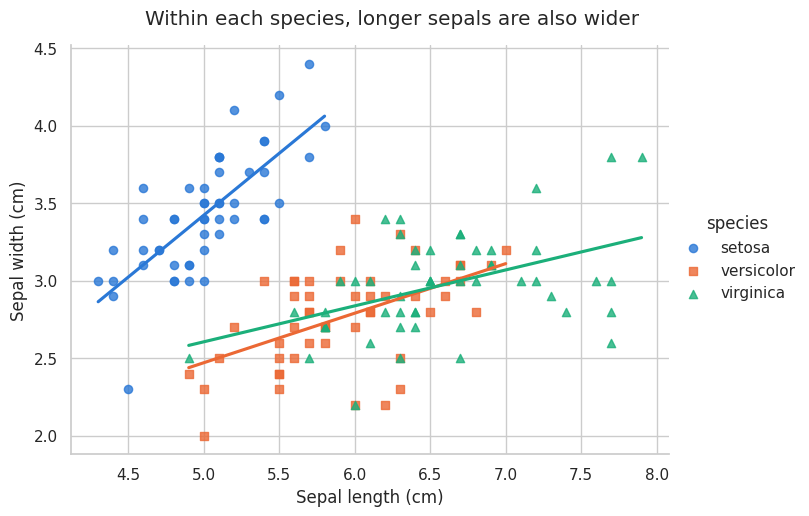

In [48]:
# lmplot fits a straight line for each species
g = sns.lmplot(data=df, x="sepal_length", y="sepal_width", hue="species",
               palette=SPECIES_COLOURS, markers=["o", "s", "^"], ci=None,
               height=5, aspect=1.4, scatter_kws={"s": 35})
g.set_axis_labels("Sepal length (cm)", "Sepal width (cm)")
g.figure.suptitle("Within each species, longer sepals are also wider", y=1.03)
plt.show()

Across all flowers the correlation is slightly **negative**, but within every species it is
**positive**. Mixing groups together can reverse a relationship; this is an example of
**Simpson's paradox**, and a good reason to always explore by group.

### Chart 12: Smoothed distributions (KDE plot)

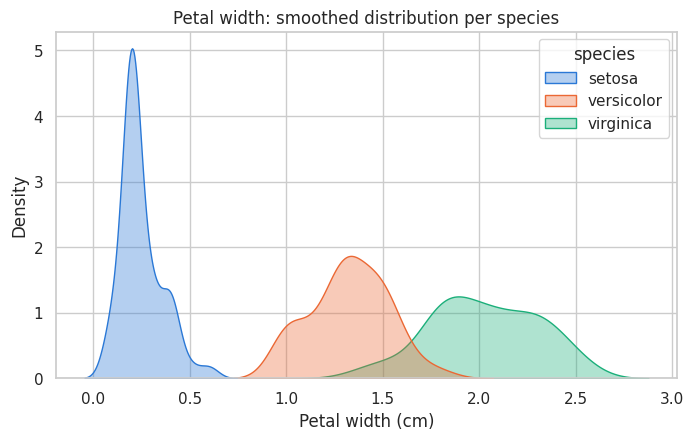

In [49]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=df, x="petal_width", hue="species", palette=SPECIES_COLOURS,
            fill=True, alpha=0.35, common_norm=False, ax=ax)
ax.set_title("Petal width: smoothed distribution per species")
ax.set_xlabel("Petal width (cm)")
plt.show()

### Chart 13: Average measurements per species (grouped bar chart)

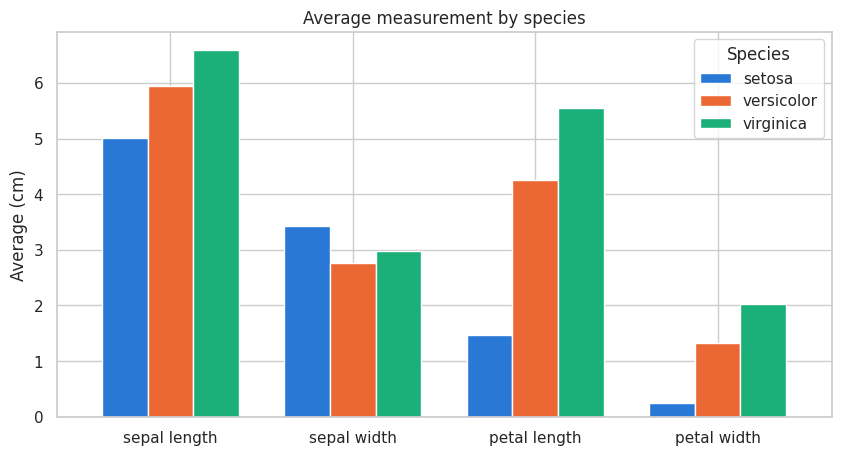

In [50]:
means = df.groupby("species")[features].mean().reindex(SPECIES_COLOURS.keys())

# Each group of bars is one measurement; each bar within it is one species
ax = means.T.plot(kind="bar", figsize=(10, 5), width=0.75, edgecolor="white",
                  color=[SPECIES_COLOURS[s] for s in means.index])
ax.set_title("Average measurement by species")
ax.set_xlabel("")
ax.set_ylabel("Average (cm)")
ax.set_xticklabels([f.replace("_", " ") for f in features], rotation=0)
ax.legend(title="Species")
plt.show()

### Chart 14: All four measurements for every flower (parallel coordinates)

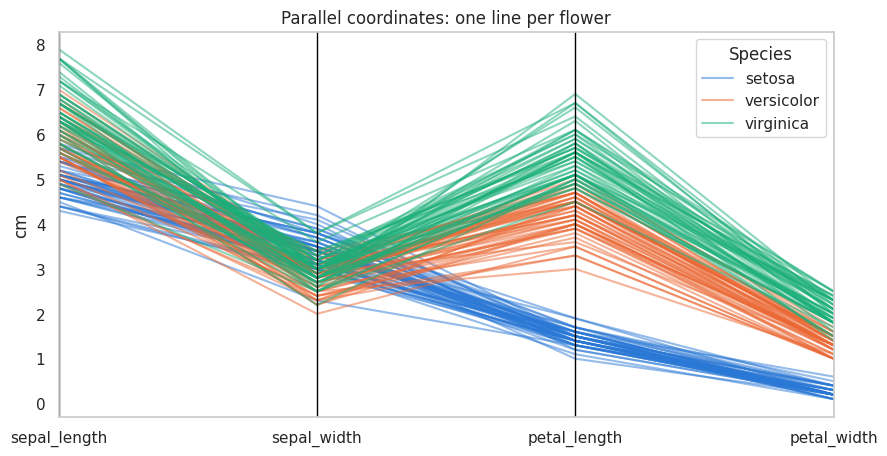

In [51]:
from pandas.plotting import parallel_coordinates

fig, ax = plt.subplots(figsize=(10, 5))
# Each line is one flower, joining its 4 measurements
parallel_coordinates(df[features + ["species"]], "species",
                     color=list(SPECIES_COLOURS.values()), alpha=0.5, ax=ax)
ax.set_title("Parallel coordinates: one line per flower")
ax.set_ylabel("cm")
ax.legend(title="Species")
plt.show()

Lines of the same colour follow a similar path; where the colours separate, that measurement is useful.

### Chart 15 (bonus): All four measurements squashed into two with PCA

**Principal Component Analysis (PCA)** finds new axes that keep as much of the variation as possible.
Here we reduce 4 measurements to 2 so we can plot every flower on one chart.

Share of variation kept by each component: [0.73  0.229]


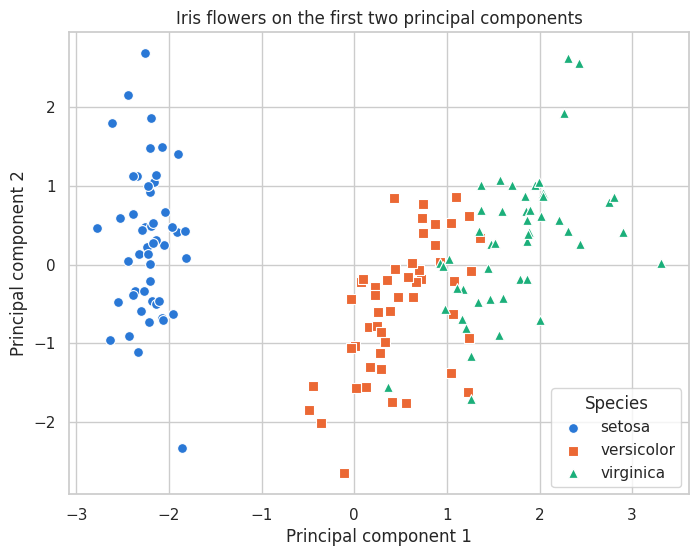

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale the features first so each has mean 0 and standard deviation 1
X_scaled = StandardScaler().fit_transform(df[features])

# Keep 2 principal components
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
print("Share of variation kept by each component:", pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
for species, colour in SPECIES_COLOURS.items():
    mask = (df["species"] == species).to_numpy()
    ax.scatter(components[mask, 0], components[mask, 1], color=colour,
               marker=SPECIES_MARKERS[species], label=species, s=50,
               edgecolor="white", linewidth=0.8)
ax.set_title("Iris flowers on the first two principal components")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.legend(title="Species")
plt.show()

---
## 16. What have we learned?

- The data is **clean**: 150 rows, no missing values, one duplicate row, and **balanced** classes.
- **Petal** measurements separate the species far better than **sepal** measurements.
- **Setosa** is easy to identify; **versicolor** and **virginica** overlap slightly, so that is
  where a model will make its mistakes.
- Petal length and petal width are strongly correlated, so they carry similar information.
- Looking at the data **by group** can reveal patterns that overall numbers hide.

These findings tell us what to expect before we train a classifier such as KNN or a decision tree.

## 17. Your turn

1. Which species has the **widest** sepals on average? Use `groupby`.
2. How many **virginica** flowers have a petal width below 1.5 cm? Use a filter.
3. Add a column `sepal_area` and draw a box plot of it by species. Is it a useful feature?
4. Draw a scatter plot of **sepal length vs petal length**. Is this pair better or worse than the petals alone?
5. Change the `bins` in Chart 2 to 5 and then to 50. How does the story change?
6. **Challenge:** repeat the exploration on the Palmer Penguins data: `sns.load_dataset("penguins")`.
   Watch out: that dataset **does** have missing values.